# Training the CNN

In [1]:
# Verifying the availability of colab's gpu
!nvidia-smi

Wed Mar 11 06:34:29 2026       
+-----------------------------------------------------------------------------------------+
| NVIDIA-SMI 580.82.07              Driver Version: 580.82.07      CUDA Version: 13.0     |
+-----------------------------------------+------------------------+----------------------+
| GPU  Name                 Persistence-M | Bus-Id          Disp.A | Volatile Uncorr. ECC |
| Fan  Temp   Perf          Pwr:Usage/Cap |           Memory-Usage | GPU-Util  Compute M. |
|                                         |                        |               MIG M. |
|=========================================+========================+======================|
|   0  Tesla T4                       Off |   00000000:00:04.0 Off |                    0 |
| N/A   35C    P8             11W /   70W |       0MiB /  15360MiB |      0%      Default |
|                                         |                        |                  N/A |
+-----------------------------------------+-----

In [26]:
# Installing MedMNIST on the Runtime
%pip install medmnist torch torchvision tqdm onnxscript onnx

### Step 1: Environment Setup


In [27]:
# Importing dependencies
# For dataset
import medmnist
from medmnist import INFO, Evaluator

# For splitting and training the model
import torch
import torch.nn as nn
import torch.optim as optim
from torchvision import transforms
from torch.utils.data import DataLoader, Subset
from torchvision.models import resnet18, ResNet18_Weights
from tqdm import tqdm

# Splitting the dataset to train and validation
from sklearn.model_selection import train_test_split

# For Evaluation of the model
import matplotlib.pyplot as plt
from sklearn.metrics import confusion_matrix, classification_report
import seaborn as sns
import numpy as np
import os
import inspect
import random

# For storing and updating the best model weights
import copy

import onnx

### Step 2: Data Loading (MedMNIST)

In [4]:
data_flag = 'pneumoniamnist' # We can change this to 'chestmnist' or 'skinmnist' 
info = INFO[data_flag]
DataClass = getattr(medmnist, info['python_class'])
info

{'python_class': 'PneumoniaMNIST',
 'description': 'The PneumoniaMNIST is based on a prior dataset of 5,856 pediatric chest X-Ray images. The task is binary-class classification of pneumonia against normal. We split the source training set with a ratio of 9:1 into training and validation set and use its source validation set as the test set. The source images are gray-scale, and their sizes are (384−2,916)×(127−2,713). We center-crop the images and resize them into 1×28×28.',
 'url': 'https://zenodo.org/records/10519652/files/pneumoniamnist.npz?download=1',
 'MD5': '28209eda62fecd6e6a2d98b1501bb15f',
 'url_64': 'https://zenodo.org/records/10519652/files/pneumoniamnist_64.npz?download=1',
 'MD5_64': '8f4eceb4ccffa70c672198ea285246c6',
 'url_128': 'https://zenodo.org/records/10519652/files/pneumoniamnist_128.npz?download=1',
 'MD5_128': '05b46931834c231683c68f40c47b2971',
 'url_224': 'https://zenodo.org/records/10519652/files/pneumoniamnist_224.npz?download=1',
 'MD5_224': 'd6a3c71de1b94

### What is ResNet-18 and why I have chosen it?

Deep convolutional neural networks have led a series of breakthroughs for image classification. CNN’s were creating industry leading performance models enriched by the number of stacked layers.

However, this led to a natural question: Is learning better networks as easy as stacking more layers? Researchers learned that this is not always the case and have discovered a new novel approach to achieve even better performant models, the ResNet (Residual Network) family.

Originally introduced in the paper, “Deep Residual Learning for Image Recognition”, the ResNet family is a CNN based architecture with a groundbreaking concept called **residual connections**. 

What Is ResNet-18? 

As part of the ResNet family, ResNet-18 is the smallest and most lightweight model, making it a popular choice for fast experimentation, deployment, and educational use. Additionally, ResNet-18 is the goto model for image classification and is a reliable starting point balancing speed, accuracy, and simplicity. For longer training times and potentially better accuracy, within the family is ResNet-34, ResNet-50, ResNet-101, etc.

Why choose ResNet-18?

ResNet-18 is the goto model when working with smaller datasets or constrained computational environments. It shines in common scenarios such as prototyping computer vision models quickly, educational projects that require interpretability and fast training, and any case where one would need the speed with smaller size. Despite its smaller size, ResNet-18 has proven to be a strong baseline in many benchmarks.

Source : https://blog.roboflow.com/resnet-18/

In [5]:
# 1. Define standard preprocessing 
transform = transforms.Compose([
    transforms.Resize(224), 
    transforms.Grayscale(num_output_channels=3), 
    transforms.ToTensor(),
    transforms.Normalize(mean=[.5], std=[.5])
])

BATCH_SIZE = 32

# 2. Load raw datasets from MedMNIST
full_train_dataset = DataClass(split='train', transform=transform, download=True)
test_dataset = DataClass(split='test', transform=transform, download=True)

# 3. Create the Validation Split (80% Train, 20% Val)
# We extract the labels to perform a 'stratified' split
labels = [label[0] for label in full_train_dataset.labels]

train_idx, val_idx = train_test_split(
    list(range(len(full_train_dataset))),
    test_size=0.20,
    random_state=42,
    stratify=labels # Crucial for medical data balance
)

# 4. Create Subset objects
train_subset = Subset(full_train_dataset, train_idx)
val_subset = Subset(full_train_dataset, val_idx)

# 5. Define Loaders
train_loader = DataLoader(dataset=train_subset, batch_size=BATCH_SIZE, shuffle=True)
val_loader = DataLoader(dataset=val_subset, batch_size=BATCH_SIZE, shuffle=False)
test_loader = DataLoader(dataset=test_dataset, batch_size=BATCH_SIZE, shuffle=False)

print(f"Training samples: {len(train_subset)}")
print(f"Validation samples: {len(val_subset)}")
print(f"Test samples: {len(test_dataset)}")

100%|██████████| 4.17M/4.17M [00:01<00:00, 3.36MB/s]

Training samples: 3766
Validation samples: 942
Test samples: 624


### Step 3: The Model (ResNet-18)

In [6]:
# Confirming GPU is available
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
device

device(type='cuda')

In [7]:
# Loading the model
model = resnet18(weights=ResNet18_Weights.DEFAULT)
model.fc = nn.Linear(model.fc.in_features, len(info['label'])) # Adjust for classes
model = model.to(device)

# CrossEntropyLoss on giving a bad prediciton has a very high value as compared to other loss (eg SSR) which helps in backpropagation as we can optimize faster than.
criterion = nn.CrossEntropyLoss()

# Adam (Adaptive Moment Estimation) optimizer combines the advantages of Momentum and RMSprop techniques to adjust learning rates during training. It works well with large datasets and complex models because it uses memory efficiently and adapts the learning rate for each parameter automatically.
# For more and reference visit: https://www.geeksforgeeks.org/deep-learning/adam-optimizer/
optimizer = optim.Adam(model.parameters(), lr=0.001)

Downloading: "https://download.pytorch.org/models/resnet18-f37072fd.pth" to /root/.cache/torch/hub/checkpoints/resnet18-f37072fd.pth


100%|██████████| 44.7M/44.7M [00:00<00:00, 180MB/s]


### Step 4: Training Loop with History Tracking

In [15]:
NUM_EPOCHS = 10

best_acc = 0.0
best_model_wts = copy.deepcopy(model.state_dict())
train_losses = []

for epoch in range(NUM_EPOCHS):
    # --- Training Phase ---
    model.train()
    epoch_loss = 0
    for inputs, targets in train_loader:
        inputs, targets = inputs.to(device), targets.to(device).long().squeeze()
        optimizer.zero_grad()
        outputs = model(inputs)
        loss = criterion(outputs, targets)
        loss.backward()
        optimizer.step()
        epoch_loss += loss.item()

    # Calculate average loss for the epoch and store it
    train_losses.append(epoch_loss / len(train_loader))
    
    # --- Validation Phase ---
    model.eval()
    val_corrects = 0
    with torch.no_grad():
        for inputs, targets in val_loader:
            inputs, targets = inputs.to(device), targets.to(device).long().squeeze()
            outputs = model(inputs)
            _, preds = torch.max(outputs, 1)
            val_corrects += torch.sum(preds == targets.data)

    epoch_val_acc = val_corrects.double() / len(val_subset)
    print(f'Epoch {epoch+1}/{NUM_EPOCHS} | Val Acc: {epoch_val_acc:.4f}')

    # --- Checkpoint Logic ---
    if epoch_val_acc > best_acc:
        best_acc = epoch_val_acc
        best_model_wts = copy.deepcopy(model.state_dict())
        # Save the physical file immediately
        torch.save(best_model_wts, 'best_vision_model.pth')
        print(f"New best accuracy! Model weights updated.")

# Final Step: Load the best found weights back into the model
model.load_state_dict(best_model_wts)
print(f"Training complete. Best Val Acc: {best_acc:.4f}")

Epoch 1/10 | Val Acc: 0.9501
New best accuracy! Model weights updated.
Epoch 2/10 | Val Acc: 0.9586
New best accuracy! Model weights updated.
Epoch 3/10 | Val Acc: 0.9756
New best accuracy! Model weights updated.
Epoch 4/10 | Val Acc: 0.9575
Epoch 5/10 | Val Acc: 0.9607
Epoch 6/10 | Val Acc: 0.9745
Epoch 7/10 | Val Acc: 0.9788
New best accuracy! Model weights updated.
Epoch 8/10 | Val Acc: 0.9724
Epoch 9/10 | Val Acc: 0.9607
Epoch 10/10 | Val Acc: 0.9777
Training complete. Best Val Acc: 0.9788


### Why save only model weights and not the object model?

* **Smaller File Size**: Weights-only files (e.g., .pt, .h5, or state_dict) contain only the numerical parameters, not the model architecture or code. This significantly reduces storage and transfer overhead

* **Portability and Flexibility**: Weights can be loaded into different frameworks or architectures, enabling reuse across platforms (e.g., PyTorch to TensorFlow via conversion tools).

* **Research Based** : Saved weights can be loaded again for fine tuning.

Sources used : 
* https://medium.com/data-science/everything-you-need-to-know-about-saving-weights-in-pytorch-572651f3f8de
* https://www.dailydoseofds.com/mlops-crash-course-part-11/
* https://www.ultralytics.com/glossary/model-weights


In [16]:
best_model_wts

OrderedDict([('conv1.weight',
              tensor([[[[ 1.2904e-02,  1.1280e-02,  1.0141e-02,  ...,  6.0722e-02,
                          1.6730e-02, -1.7855e-02],
                        [ 3.5714e-02,  2.7440e-02, -9.7897e-02,  ..., -2.6783e-01,
                         -1.2994e-01, -1.6481e-03],
                        [ 1.6196e-02,  7.5096e-02,  3.0541e-01,  ...,  5.2129e-01,
                          2.5357e-01,  5.6503e-02],
                        ...,
                        [-1.0775e-02,  2.5595e-02,  7.6580e-02,  ..., -3.3711e-01,
                         -4.2880e-01, -2.7055e-01],
                        [ 4.6311e-02,  4.9862e-02,  6.6091e-02,  ...,  4.0787e-01,
                          3.8364e-01,  1.5001e-01],
                        [-3.0956e-04,  5.6083e-03, -2.0533e-02,  ..., -1.5576e-01,
                         -9.3625e-02, -2.1346e-02]],
              
                       [[ 1.1926e-02, -9.2031e-03, -2.2691e-02,  ...,  3.6628e-02,
                          3.0940

In [19]:
# Saving the model
current_dir = os.path.dirname(os.path.abspath(inspect.getfile(lambda: None)))
FILE_NAME = "cnn_vision_v1.pth"
final_save_path = os.path.join(current_dir, '..', '..', 'models', FILE_NAME)
os.makedirs(os.path.dirname(final_save_path), exist_ok=True)
torch.save(best_model_wts, final_save_path)

In [20]:
final_save_path

'/tmp/ipykernel_3115/../../models/cnn_vision_v1.pth'

Here the model is saved in a remote environment and not the local so to save the model we first create a download link and save the local file which contains weights there

In [ ]:
import base64
from IPython.display import HTML

def create_download_link(file_path):
    with open(file_path, "rb") as f:
        data = f.read()
    b64 = base64.b64encode(data).decode()
    filename = os.path.basename(file_path)
    # This creates a link you can click inside VS Code
    return HTML(f'<a href="data:application/octet-stream;base64,{b64}" download="{filename}">Click here to download {filename}</a>')

# Use the absolute path we found earlier
create_download_link(final_save_path)

### Step 5: Performance Evaluation

--- Clinical Classification Report ---
              precision    recall  f1-score   support

      normal       0.99      0.65      0.78       234
   pneumonia       0.82      0.99      0.90       390

    accuracy                           0.86       624
   macro avg       0.91      0.82      0.84       624
weighted avg       0.88      0.86      0.86       624



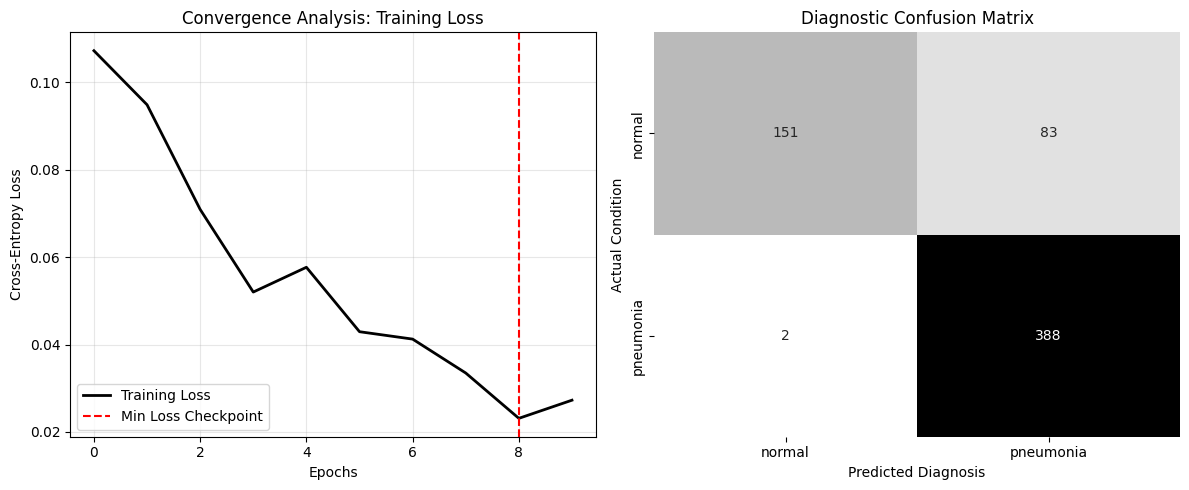

In [17]:
# 1. Load the Best Weights for Final Evaluation
model.load_state_dict(best_model_wts)
model.eval()

all_preds = []
all_labels = []

# 2. Run Inference on the Test Loader
with torch.no_grad():
    for inputs, targets in test_loader:
        inputs = inputs.to(device)
        outputs = model(inputs)
        _, preds = torch.max(outputs, 1)
        
        all_preds.extend(preds.cpu().numpy())
        # MedMNIST targets are often (N, 1), so we flatten
        all_labels.extend(targets.cpu().numpy().flatten())

# 3. Print Clinical Metrics
print("--- Clinical Classification Report ---")
print(classification_report(all_labels, all_preds, target_names=list(info['label'].values())))

# 4. --- PLOTTING FOR DISSERTATION ---
plt.figure(figsize=(12, 5))

# Plot 1: Loss Progression (Ensure you saved 'train_losses' in your loop)
plt.subplot(1, 2, 1)
plt.plot(train_losses, label='Training Loss', color='black', linewidth=2)
plt.axvline(x=np.argmin(train_losses), color='red', linestyle='--', label='Min Loss Checkpoint')
plt.title('Convergence Analysis: Training Loss', fontsize=12)
plt.xlabel('Epochs')
plt.ylabel('Cross-Entropy Loss')
plt.legend()
plt.grid(True, alpha=0.3)

# Plot 2: Confusion Matrix (Medical Diagnostics Focus)
plt.subplot(1, 2, 2)
cm = confusion_matrix(all_labels, all_preds)
sns.heatmap(cm, annot=True, fmt='d', cmap='Greys', 
            xticklabels=info['label'].values(), 
            yticklabels=info['label'].values(),
            cbar=False)
plt.title('Diagnostic Confusion Matrix', fontsize=12)
plt.xlabel('Predicted Diagnosis')
plt.ylabel('Actual Condition')

plt.tight_layout()
plt.show()

In [32]:
# 1. Reconstruct Architecture
final_model = resnet18(weights=ResNet18_Weights.DEFAULT)
num_ftrs = final_model.fc.in_features
final_model.fc = nn.Linear(num_ftrs, 2)


# 2. Load best weights
final_model.load_state_dict(best_model_wts)
print("Weights loaded from memory.")

final_model.eval()
final_model.to('cpu')

# 3. Dummy input
dummy_input = torch.randn(1, 3, 224, 224)

# Saving the ONNX model
current_dir = os.path.dirname(os.path.abspath(inspect.getfile(lambda: None)))
ONNX_FILE_NAME = "vision_production_v1.onnx"
final_onnx_save_path = os.path.join(current_dir, '..', '..', 'models', ONNX_FILE_NAME)
os.makedirs(os.path.dirname(final_onnx_save_path), exist_ok=True)

# 4. Force legacy TorchScript exporter — this reliably bakes weights
with torch.no_grad():
    torch.onnx.export(
        final_model,
        dummy_input,
        final_onnx_save_path,
        export_params=True,
        opset_version=18,
        do_constant_folding=True,
        input_names=['input'],
        output_names=['output'],
        dynamo=False              # ← KEY FIX: forces legacy exporter
    )

# 5. Verify
file_size = os.path.getsize(final_onnx_save_path) / (1024 * 1024)
model_check = onnx.load(final_onnx_save_path)
onnx.checker.check_model(model_check)

if file_size > 40:
    print(f"SUCCESS! {final_onnx_save_path} exported.")
    print(f"File Size : {file_size:.2f} MB")
    print(f" ONNX opset: {model_check.opset_import[0].version}")
else:
    print(f"File size {file_size:.2f} MB — weights still missing.")

Weights loaded from memory.


/tmp/ipykernel_3115/902149721.py:25: DeprecationWarning: You are using the legacy TorchScript-based ONNX export. Starting in PyTorch 2.9, the new torch.export-based ONNX exporter has become the default. Learn more about the new export logic: https://docs.pytorch.org/docs/stable/onnx_export.html. For exporting control flow: https://pytorch.org/tutorials/beginner/onnx/export_control_flow_model_to_onnx_tutorial.html
  torch.onnx.export(


SUCCESS! /tmp/ipykernel_3115/../../models/vision_production_v1.onnx exported.
File Size : 42.63 MB
 ONNX opset: 18


In [ ]:
create_download_link(final_onnx_save_path)